# Libraries

In [1]:
from scipy.io import loadmat
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, IntSlider, FloatSlider, Dropdown
from scipy.ndimage import binary_dilation
from skimage.transform import resize
from skimage.draw import disk
import pandas as pd
import json

# Select the patient (1 or 3)

In [2]:
dir="./Patient_1"
data = loadmat(f"{dir}/Combined/CON_0101SP_12072016_tumor_all.mat")
dir_3 ="./Patient_3"
data_3=loadmat(f"{dir_3}/Combined/CON_03_V01_tumor_all.mat")

for k, v in data.items():
    if not k.startswith("__"):
        print(k, type(v), getattr(v, "shape", ""))
    
for k, v in data_3.items():
    if not k.startswith("__"):
        print(k, type(v), getattr(v, "shape", ""))


brain_mask <class 'numpy.ndarray'> (108, 108, 66)
bv_all <class 'numpy.ndarray'> (1, 17)
fullbrain_all <class 'numpy.ndarray'> (108, 108, 66, 13)
noisemap_all <class 'numpy.ndarray'> (108, 108, 66, 13)
tumor_all <class 'numpy.ndarray'> (108, 108, 66, 13)
tumor_mask <class 'numpy.ndarray'> (108, 108, 66)
brain_mask <class 'numpy.ndarray'> (108, 108, 66)
bv_all <class 'numpy.ndarray'> (1, 16)
fullbrain_all <class 'numpy.ndarray'> (108, 108, 66, 12)
noisemap_all <class 'numpy.ndarray'> (108, 108, 66, 12)
tumor_all <class 'numpy.ndarray'> (108, 108, 66, 12)
tumor_mask <class 'numpy.ndarray'> (108, 108, 66)


# Investigate the structure of the data

In [3]:
print(data.keys())
print(data["__header__"])
print(data["__version__"])
print(data["__globals__"])

dict_keys(['__header__', '__version__', '__globals__', 'brain_mask', 'bv_all', 'fullbrain_all', 'noisemap_all', 'tumor_all', 'tumor_mask'])
b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Thu Oct  9 15:29:28 2025'
1.0
[]


In [4]:
brain_mask=data["brain_mask"]
bv_all=data["bv_all"]
bv_all_3=data_3["bv_all"]
fullbrain_all=data["fullbrain_all"]
noisemap_all=data["noisemap_all"]
tumor_all=data["tumor_all"]
tumor_mask=data["tumor_mask"]

In [5]:
print(f"Brain mask shape is {brain_mask.shape}")
print(f"B value shape is {bv_all.shape}")
print(f"Full brain shape is {fullbrain_all.shape}")
print(f"Noise map shape is {noisemap_all.shape}")
print(f"Tumor all shape is {tumor_all.shape}")
print(f"Tumor mask shape is {tumor_mask.shape}")
print(f"b-values for patient 1: {bv_all}")
print(f"b-values for patient 3: {bv_all_3}")

Brain mask shape is (108, 108, 66)
B value shape is (1, 17)
Full brain shape is (108, 108, 66, 13)
Noise map shape is (108, 108, 66, 13)
Tumor all shape is (108, 108, 66, 13)
Tumor mask shape is (108, 108, 66)
b-values for patient 1: [[    0   100   500  1300     0  2600  4200  6000     0   200   700  1400
      0  3800  7300 12000 17800]]
b-values for patient 3: [[    0   100   500  1300     0  2600  4200  6000     0   700  1400     0
   3800  7300 12000 17800]]


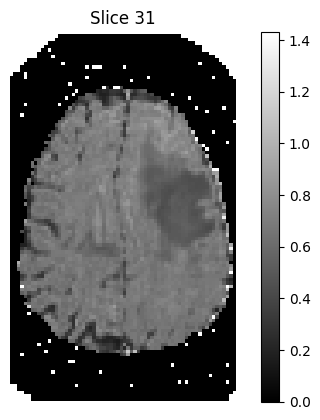

In [6]:
name='fullbrain_all'
signal=data[name] #sagitarial plan
signal_t=np.transpose(signal, (0,2,1,3)) #transverse plan
slice=signal_t[:,:,31,1]
plt.imshow(slice,cmap="gray")
plt.colorbar()
plt.title("Slice 31")
plt.axis('off')
plt.show()

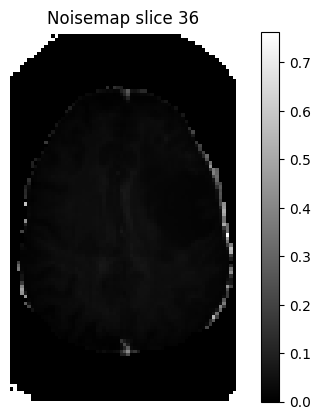

In [7]:
name='noisemap_all'
signal=data[name] #sagitarial plan
signal_t=np.transpose(signal, (0,2,1,3)) #transverse plan
slice=signal_t[:,:,31,1]
plt.imshow(slice,cmap="gray")
plt.colorbar()
plt.title("Noisemap slice 36")
plt.axis('off')
plt.show()

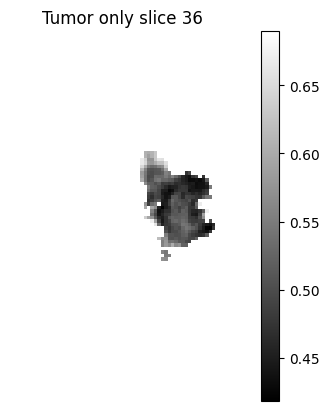

In [8]:
name='tumor_all'
signal=data[name] #sagitarial plan
signal_t=np.transpose(signal, (0,2,1,3)) #transverse plan
slice=signal_t[:,:,31,1]
plt.imshow(slice,cmap="gray")
plt.colorbar()
plt.title("Tumor only slice 36")
plt.axis('off')
plt.show()

# Finding the slide from the article

In [9]:
def browse_slices(slice_idx):

    t_mask = np.transpose(data["tumor_mask"], (0,2,1))
    plt.figure(figsize=(6,6))
    plt.imshow(t_mask[:, :, slice_idx], cmap='gray')
    plt.title(f"Slice index: {slice_idx}")
    plt.axis('off')
    plt.show()


interact(browse_slices, slice_idx=IntSlider(min=0, max=data["tumor_mask"].shape[2]-1, step=1, value=31))

#Slice represented in the paper
#Patient 1 = 36
#Patient 2 = 31

interactive(children=(IntSlider(value=31, description='slice_idx', max=65), Output()), _dom_classes=('widget-i…

<function __main__.browse_slices(slice_idx)>

# Find ROI coordinates on DWI

In [10]:
# Load the patient file
#img_article = plt.imread("./Patient_1/Patient_1_DWI.png") 
img_article = plt.imread("./Patient_3/Patient_3_DWI.png") 

# Extract the DWI slice
mri_slice = np.transpose(data_3["fullbrain_all"], (0,2,1,3))[:, :, 31, 0] # 36 for patient 1 and 31 for patient 3
t_mask = np.transpose(data_3["tumor_mask"], (0,2,1))[:, :, 31].astype(bool) #36 for patient 1 and 31 for patient 3

# Resize the article image to fit the DWI
img_article_rescaled = resize(img_article, mri_slice.shape)

def fine_tuning_registration(y_center, x_center,
                             offset_y, offset_x,
                             zoom,
                             roi_shape,
                             roi_width,
                             roi_height,
                             roi_radius,
                             alpha_art=0.5):

    H, W = mri_slice.shape
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # --- MRI + mask ---
    ax.imshow(mri_slice, cmap='gray')
    ax.contour(t_mask, colors='cyan', linewidths=1.5)
    
    # --- Article overlay ---
    left = offset_x
    right = W * zoom + offset_x
    bottom = H * zoom + offset_y
    top = offset_y
    
    ax.imshow(img_article, alpha=alpha_art,
              extent=[left, right, bottom, top])

    # --- ROI mask ---
    roi_mask = np.zeros((H, W))

    if roi_shape == "rectangle":
        y_s = y_center - roi_height // 2
        x_s = x_center - roi_width // 2
        
        roi_mask[
            max(0, y_s):min(H, y_s + roi_height),
            max(0, x_s):min(W, x_s + roi_width)
        ] = 1

    elif roi_shape == "disque":
        rr, cc = disk((y_center, x_center), roi_radius, shape=roi_mask.shape)
        roi_mask[rr, cc] = 1

    ax.imshow(roi_mask, cmap='Accent', alpha=0.6 if np.any(roi_mask) else 0)

    ax.set_xlim(0, W)
    ax.set_ylim(H, 0)
    ax.set_title("Overlapping to find ROI coordinates")
    plt.show()

interact(
    fine_tuning_registration,
    
    y_center=IntSlider(min=0, max=mri_slice.shape[0], step=1, value=64),
    x_center=IntSlider(min=0, max=mri_slice.shape[1], step=1, value=64),
    
    offset_y=IntSlider(min=-20, max=20, step=1, value=0),
    offset_x=IntSlider(min=-20, max=20, step=1, value=0),
    
    zoom=FloatSlider(min=0.8, max=1.2, step=0.01, value=1.0),
    
    roi_shape=Dropdown(options=["rectangle", "disque"], value="rectangle"),
    
    roi_width=IntSlider(min=2, max=50, step=1, value=7),
    roi_height=IntSlider(min=2, max=50, step=1, value=7),
    roi_radius=IntSlider(min=2, max=30, step=1, value=5),
    
    alpha_art=(0.0, 1.0, 0.05)
)


#Patient 1 
#xcenter=49
#ycenter=49
#edge=7

#Patient 3
#xcenter=28
#ycenter=73
#edge=3

interactive(children=(IntSlider(value=64, description='y_center', max=108), IntSlider(value=64, description='x…

<function __main__.fine_tuning_registration(y_center, x_center, offset_y, offset_x, zoom, roi_shape, roi_width, roi_height, roi_radius, alpha_art=0.5)>

# Graph for all bvalues

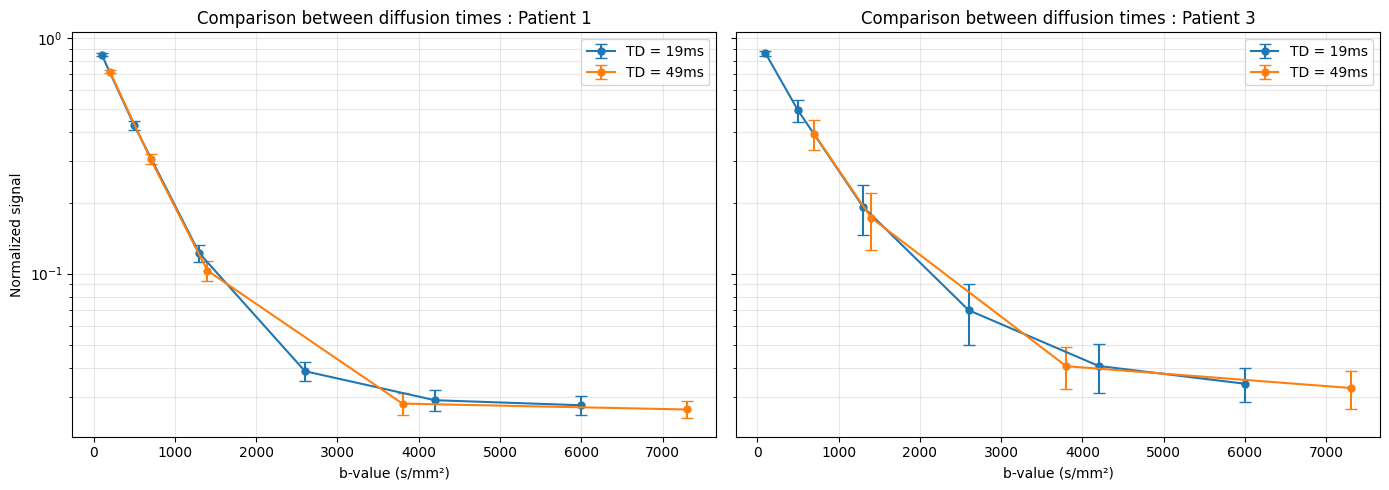

In [11]:
def extract_patient_curves(data_dict, slice_idx, center, roi_size, roi_type='square'):
    """
    data_dict: dictionnary from loadmat
    slice_idx: slice index (36 for P1, 31 for P3)
    center: (y, x) roi center coordinates
    roi_size: edge length for square or radius for circle
    roi_type: 'square' or 'circle'
    """
    # Prepare volume
    full_brain = np.transpose(data_dict["fullbrain_all"], (0, 2, 1, 3))
    signal_slice = full_brain[:, :, slice_idx, :]
    
    # Clean bvalues and identify blocks
    H, W, num_b = signal_slice.shape
    b_values = data_dict["bv_all"].flatten()
    zero_idx = np.where(b_values == 0)[0]
    split_points = np.concatenate(([ -1 ], zero_idx, [ len(b_values) ]))

    blocks = []
    for i in range(len(split_points)-1):
        start = split_points[i] + 1
        end = split_points[i+1]
        block = b_values[start:end]
        if len(block) > 0:
            blocks.append(block)
    
    final_bvalues = [b for block in blocks for b in block]
    ind_mid = len(blocks[0])+len(blocks[1]) 
    
    # Create ROI mask
    Y, X = np.ogrid[:H, :W]
    if roi_type == 'square':
        mask = (Y >= center[0]-roi_size) & (Y <= center[0]+roi_size) & \
               (X >= center[1]-roi_size) & (X <= center[1]+roi_size)
    else: # Circle
        mask = np.sqrt((Y - center[0])**2 + (X - center[1])**2) <= roi_size
    
    
    roi_pixels = [signal_slice[:, :, b][mask] for b in range(num_b)]
    roi_pixels_arr = np.array([p for p in roi_pixels]) 

    # Count valid voxels
    n_valid = np.sum(~np.isnan(roi_pixels_arr))
    
    # Mean signal extraction
    mean_signals = [np.nanmean(signal_slice[:, :, b][mask]) for b in range(num_b)]
    std_signals  = [np.nanstd(signal_slice[:, :, b][mask]) for b in range(num_b)]
    
    # Dataframe organization
    df = pd.DataFrame({'b_value': final_bvalues, 'signal': mean_signals, 'std':std_signals})
    
    # Create 2 series 
    df['TD'] = '49ms'
    df.iloc[:ind_mid, df.columns.get_loc('TD')] = '19ms'
    
    return df

def plot_patients_side_by_side(df_list, titles, max_b=7500):
    
    fig, axes = plt.subplots(1, len(df_list), figsize=(14, 5), sharey=True)
    
    if len(df_list) == 1:
        axes = [axes]  # sécurité si un seul subplot
    
    for ax, df, title in zip(axes, df_list, titles):
        
        df_filtered = df[df['b_value'] <= max_b]
        
        for td in df_filtered['TD'].unique():
            subset = df_filtered[df_filtered['TD'] == td]
            
            ax.errorbar(
                subset['b_value'],
                subset['signal'],
                yerr=subset['std'],
                fmt='o-',
                capsize=4,
                label=f'TD = {td}',
                markersize=5
            )
        
        ax.set_yscale('log')
        ax.set_xlabel('b-value (s/mm²)')
        ax.set_title(title)
        ax.grid(True, which="both", alpha=0.3)
        ax.legend()
    
    axes[0].set_ylabel('Normalized signal')
    
    plt.tight_layout()
    plt.show()

df_p1 = extract_patient_curves(data, slice_idx=36, center=(49, 49), roi_size=3, roi_type='square')
#print(df_p1)

df_p3 = extract_patient_curves(data_3, slice_idx=31, center=(73, 28), roi_size=3, roi_type='square')
#print(df_p3)

plot_patients_side_by_side([df_p1, df_p3], ["Comparison between diffusion times : Patient 1", "Comparison between diffusion times : Patient 3"])

# Curves with noise map

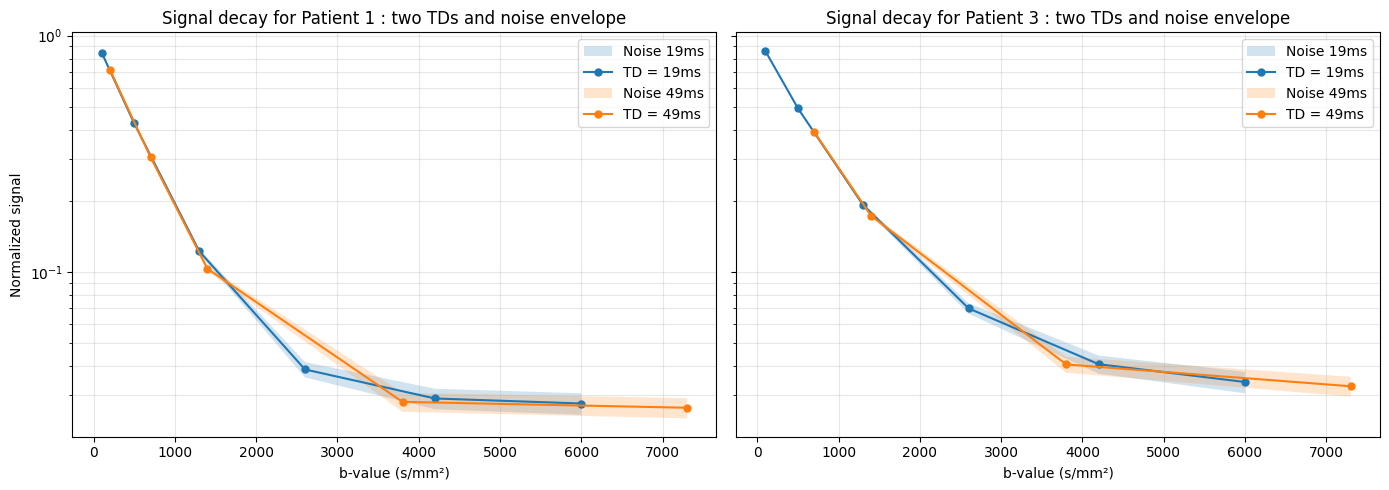

In [12]:
def extract_patient_curves(data_dict, slice_idx, center, roi_size, roi_type='square'):
    """
    Extraction of the curves for a given patient and slice, with noise envelope.
    """
    # Volume preparation
    full_brain = np.transpose(data_dict["fullbrain_all"], (0, 2, 1, 3))
    signal_slice = full_brain[:, :, slice_idx, :]
    
    noise_data = np.transpose(data_dict["noisemap_all"], (0, 2, 1, 3))
    noise_slice = noise_data[:, :, slice_idx, :]
    
    H, W, num_b_volumes = signal_slice.shape
    
    # Clean bvalues and identify blocks
    b_values = data_dict["bv_all"].flatten()
    zero_idx = np.where(b_values == 0)[0]
    split_points = np.concatenate(([-1], zero_idx, [len(b_values)]))

    blocks = []
    for i in range(len(split_points)-1):
        start = split_points[i] + 1
        end = split_points[i+1]
        block = b_values[start:end]
        if len(block) > 0:
            blocks.append(block)
    
    final_bvalues = [b for block in blocks for b in block]
    ind_mid = len(blocks[0]) + len(blocks[1])
    
    # ROI mask creation
    Y, X = np.ogrid[:H, :W]
    if roi_type == 'square':
        mask = (Y >= center[0]-roi_size) & (Y <= center[0]+roi_size) & \
               (X >= center[1]-roi_size) & (X <= center[1]+roi_size)
    else:
        mask = np.sqrt((Y - center[0])**2 + (X - center[1])**2) <= roi_size
    
    # Extraction with noise factor 1/sqrt(32)
    noise_factor = 1 / np.sqrt(32)
    
    mean_signals = []
    mean_noise = []
    std_signals = []
    
    for i in range(num_b_volumes):
        mean_signals.append(np.nanmean(signal_slice[:, :, i][mask]))
        std_signals.append(np.nanstd(signal_slice[:, :, i][mask]))
        mean_noise.append(np.nanmean(noise_slice[:, :, i][mask]) * noise_factor)
    
    # Dataframe creation
    df = pd.DataFrame({
        'b_value': final_bvalues, 
        'signal': mean_signals,
        'std': std_signals,
        'noise': mean_noise
    })
    
    df['TD'] = '49ms'
    df.iloc[:ind_mid, df.columns.get_loc('TD')] = '19ms'
    
    return df


def plot_patients_side_by_side(df_list, titles, max_b=7500):
    """
    Plotting the curves for multiple patients side by side, with noise envelope.
    """
    fig, axes = plt.subplots(1, len(df_list), figsize=(14, 5), sharey=True)
    if len(df_list) == 1:
        axes = [axes]
    
    for ax, df, title in zip(axes, df_list, titles):
        df_filtered = df[df['b_value'] <= max_b]
        
        for td in df_filtered['TD'].unique():
            subset = df_filtered[df_filtered['TD'] == td]
            
            # Noise envelope
            ax.fill_between(subset['b_value'],
                            subset['signal'] - subset['noise'],
                            subset['signal'] + subset['noise'],
                            alpha=0.2, label=f'Noise {td}')
            
            # Mean signal
            ax.plot(subset['b_value'], subset['signal'], 'o-', label=f'TD = {td}', markersize=5)
        
        ax.set_yscale('log')
        ax.set_xlabel('b-value (s/mm²)')
        ax.set_title(title)
        ax.grid(True, which="both", alpha=0.3)
        ax.legend()
    
    axes[0].set_ylabel('Normalized signal')
    plt.tight_layout()
    plt.show()

# Extraction
df_p1 = extract_patient_curves(data, slice_idx=36, center=(49, 49), roi_size=3, roi_type='square')
df_p3 = extract_patient_curves(data_3, slice_idx=31, center=(73, 28), roi_size=3, roi_type='square')

# Plot side by side with noise envelope
plot_patients_side_by_side([df_p1, df_p3], ["Signal decay for Patient 1 : two TDs and noise envelope", "Signal decay for Patient 3 : two TDs and noise envelope"])

# Noise VS H&E variability

<>:75: SyntaxWarning: invalid escape sequence '\m'
<>:75: SyntaxWarning: invalid escape sequence '\m'
C:\Users\maely\AppData\Local\Temp\ipykernel_11712\287365880.py:75: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel("b-value ($ms/\mu m^2$)")


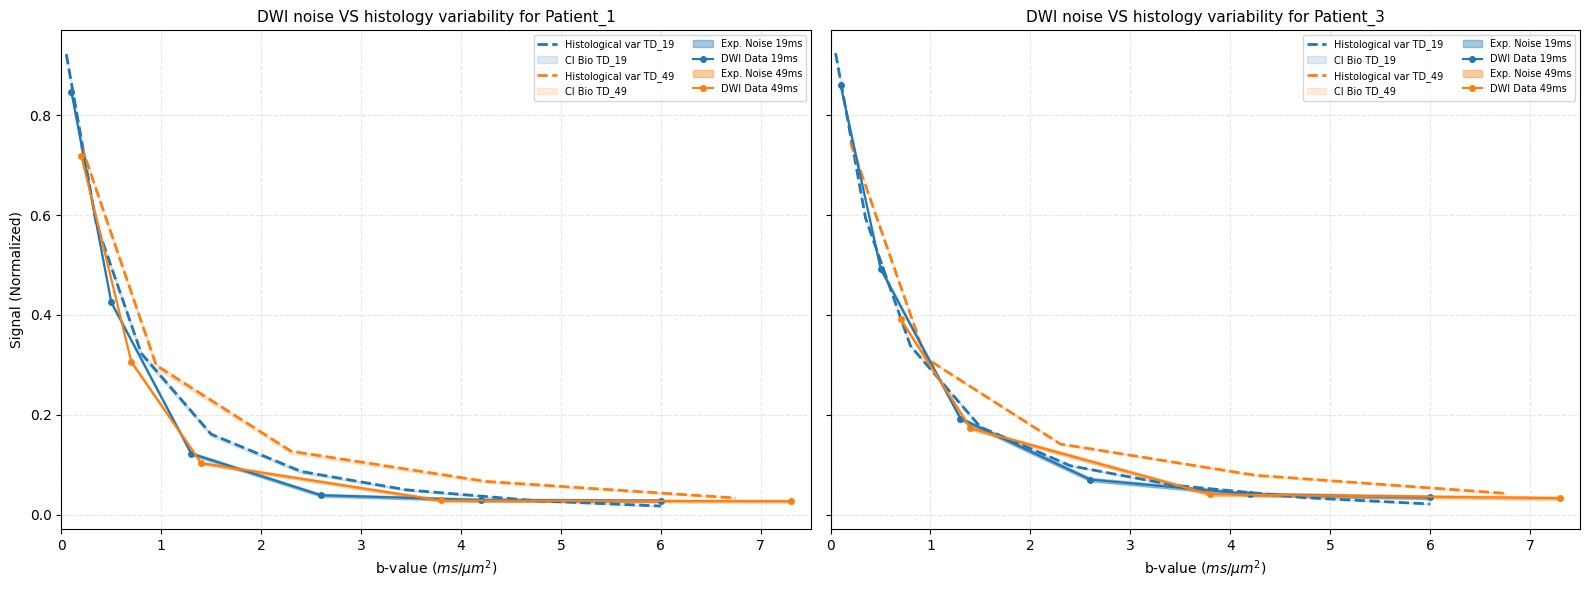

In [14]:
with open("signal_results_bootstrap.json", "r", encoding='utf-8') as f:
    signal_json=json.load(f)

def plot_dwi_vs_histo_two_patients(df_list, signal_json, pat_ids, max_b_dwi=7500, dex_selected=2.2):
    """
    Plot DWI curves with noise envelope and H&E histological data with confidence intervals for two patients side by side
    to show the insignificance of the noise compared to the variability of the histological data.
    
    df_list : list of DWI DataFrames for each patient
    signal_json : dictionnary JSON of H&E data
    pat_ids : patient IDS
    """
    TD_colors = {'TD_19': 'tab:blue', 'TD_49': 'tab:orange'}
    exp_selected = "exp_4"
    max_b_histo = max_b_dwi / 1000
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    
    for ax, df_dwi, pat_id in zip(axes, df_list, pat_ids):
        # --- HISTO ---
        td_bval_agg = {}
        if pat_id in signal_json:
            for he in signal_json[pat_id].keys():
                if exp_selected not in signal_json[pat_id][he]: continue
                for roi in signal_json[pat_id][he][exp_selected].keys():
                    roi_data = signal_json[pat_id][he][exp_selected][roi]
                    for TD_key in roi_data.keys():
                        dex_key = f"Dex_{dex_selected}"
                        if dex_key not in roi_data[TD_key]: continue
                        data = roi_data[TD_key][dex_key]
                        if TD_key not in td_bval_agg: td_bval_agg[TD_key] = {}
                        
                        bvals_h = np.array(data["bval"])
                        mask_h = bvals_h <= max_b_histo
                        
                        for b, s, l, h in zip(bvals_h[mask_h], 
                                              np.array(data["signals_median"])[mask_h], 
                                              np.array(data["p_low"])[mask_h], 
                                              np.array(data["p_high"])[mask_h]):
                            if b not in td_bval_agg[TD_key]:
                                td_bval_agg[TD_key][b] = {'s': [], 'l': [], 'h': []}
                            td_bval_agg[TD_key][b]['s'].append(s)
                            td_bval_agg[TD_key][b]['l'].append(l)
                            td_bval_agg[TD_key][b]['h'].append(h)
        
        # Histological data plotting
        for TD_key in sorted(td_bval_agg.keys()):
            b_plot = sorted(td_bval_agg[TD_key].keys())
            medians = [np.mean(td_bval_agg[TD_key][b]['s']) for b in b_plot]
            lows = [np.mean(td_bval_agg[TD_key][b]['l']) for b in b_plot]
            highs = [np.mean(td_bval_agg[TD_key][b]['h']) for b in b_plot]
            
            color = TD_colors.get(TD_key, 'black')
            ax.plot(b_plot, medians, '--', color=color, linewidth=2, label=f"Histological var {TD_key}")
            ax.fill_between(b_plot, lows, highs, color=color, alpha=0.15, label=f"CI Bio {TD_key}")
        
        # --- DWI ---
        df_filtered = df_dwi[df_dwi['b_value'] <= max_b_dwi].copy()
        for td_label in df_filtered['TD'].unique():
            subset = df_filtered[df_filtered['TD'] == td_label].sort_values('b_value')
            key_map = f"TD_{td_label.replace('ms','')}"
            color_dwi = TD_colors.get(key_map, 'black')
            
            x_dwi = subset['b_value'] / 1000
            ax.fill_between(x_dwi, 
                            subset['signal'] - subset['noise'], 
                            subset['signal'] + subset['noise'], 
                            color=color_dwi, alpha=0.4, label=f"Exp. Noise {td_label}")
            ax.plot(x_dwi, subset['signal'], 'o-', color=color_dwi, markersize=4, 
                    label=f"DWI Data {td_label}", linewidth=1.5, zorder=10)
        
        # Graph configuration
        #ax.set_yscale('log')
        ax.set_xlim(0, max_b_histo)
        ax.set_xlabel("b-value ($ms/\mu m^2$)")
        ax.set_title(f"DWI noise VS histology variability for {pat_id}", fontsize=11)
        ax.grid(True, which='both', linestyle='--', alpha=0.3)
        ax.legend(loc='upper right', fontsize=7, ncol=2)
    
    axes[0].set_ylabel("Signal (Normalized)")
    plt.tight_layout()
    plt.show()

# Test the function with both patients
plot_dwi_vs_histo_two_patients([df_p1, df_p3], signal_json, ["Patient_1", "Patient_3"])

# Comparison DWI VS H&E with Dex error bars

<>:86: SyntaxWarning: invalid escape sequence '\m'
<>:86: SyntaxWarning: invalid escape sequence '\m'
C:\Users\maely\AppData\Local\Temp\ipykernel_32604\1548957215.py:86: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel("b-value ($ms/\mu m^2$)")


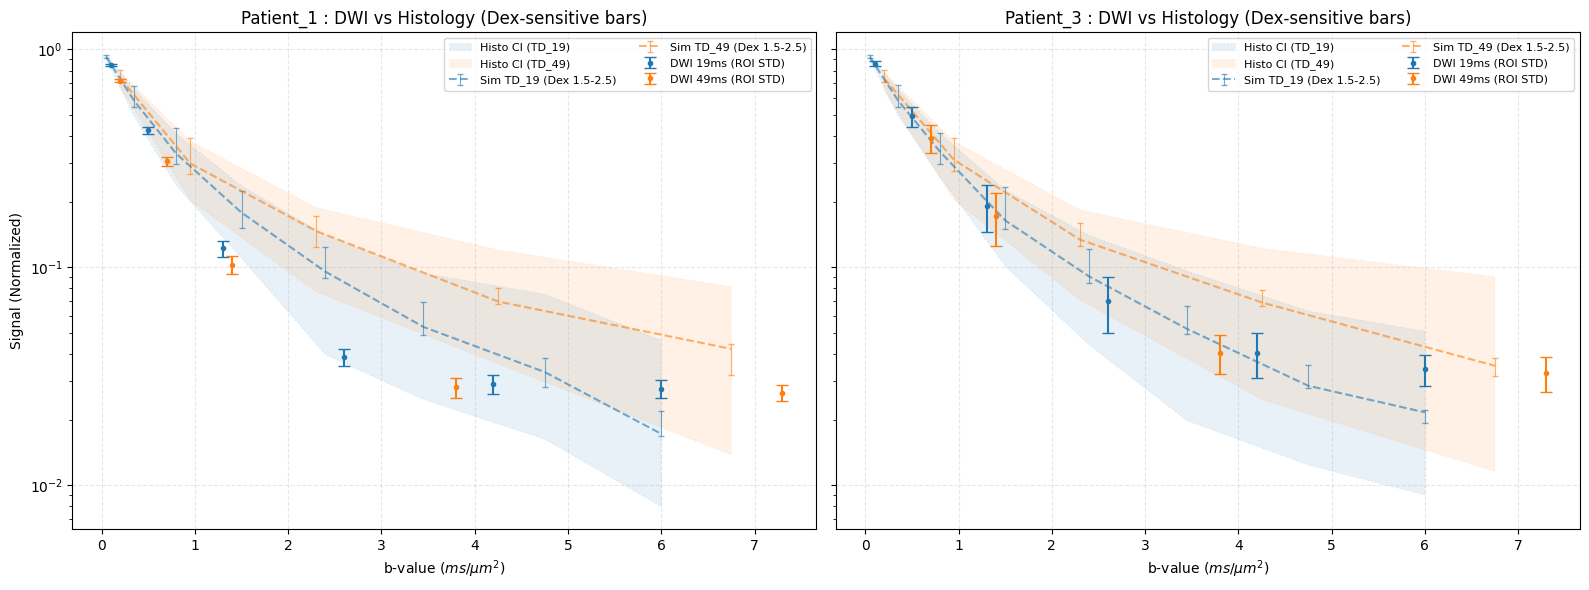

In [15]:
def plot_dwi_vs_dex_bars_two_patients(df_dwi_list, signal_json, pat_ids, max_b_histo=7.5):
    """
    Display DWI vs histology with Dex-sensitive error bars for two patients side by side.

    df_dwi_list: list of DWI DataFrames, one per patient
    pat_ids: list of patient IDs corresponding to df_dwi_list
    max_b_histo: maximum b-value for histology display (ms/um²)
    """
    Dex_min, Dex_central, Dex_max = 1.5, 2.2, 2.5
    exp_selected = "exp_4"
    TD_colors = {'TD_19': 'tab:blue', 'TD_49': 'tab:orange'}

    # Create a figure with two subplots side by side
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

    for ax, df_dwi, pat_id in zip(axes, df_dwi_list, pat_ids):
        # --- 1. HISTOLOGY (Simulation) ---
        if pat_id in signal_json:
            he_key = list(signal_json[pat_id].keys())[0]
            if exp_selected in signal_json[pat_id][he_key]:
                roi_data = signal_json[pat_id][he_key][exp_selected]
                first_roi = list(roi_data.keys())[0]
                data_roi = roi_data[first_roi]

                for TD_key in sorted(data_roi.keys()):
                    color = TD_colors.get(TD_key, 'black')

                    # Extract central, min, max Dex curves
                    d_c = data_roi[TD_key][f"Dex_{Dex_central}"]
                    d_min = data_roi[TD_key][f"Dex_{Dex_min}"]
                    d_max = data_roi[TD_key][f"Dex_{Dex_max}"]

                    b_h = np.array(d_c["bval"])
                    mask = b_h <= max_b_histo

                    s_central = np.array(d_c["signals_median"])[mask]
                    s_min = np.array(d_min["signals_median"])[mask]
                    s_max = np.array(d_max["signals_median"])[mask]

                    # Prepare asymmetric error bars for Dex sensitivity
                    yerr_dex = [
                        np.abs(s_central - s_max),  # Lower error
                        np.abs(s_min - s_central)   # Upper error
                    ]

                    # Plot simulation curves with Dex error bars
                    ax.errorbar(
                        b_h[mask], s_central, yerr=yerr_dex,
                        fmt='--', color=color, alpha=0.6,
                        capsize=2, elinewidth=0.8,
                        label=f"Sim {TD_key} (Dex {Dex_min}-{Dex_max})"
                    )

                    # Plot confidence intervals from histology
                    ax.fill_between(
                        b_h[mask],
                        np.array(d_c["p_low"])[mask],
                        np.array(d_c["p_high"])[mask],
                        color=color, alpha=0.1, linestyle=':',
                        label=f"Histo CI ({TD_key})"
                    )

        # --- 2. DWI DATA (Real measurements) ---
        df_filtered = df_dwi[df_dwi['b_value'] <= max_b_histo*1000].copy()
        for td_label in df_filtered['TD'].unique():
            subset = df_filtered[df_filtered['TD'] == td_label]
            color_dwi = TD_colors.get(f"TD_{td_label.replace('ms','')}", 'black')

            # Plot DWI points with ROI standard deviation
            ax.errorbar(
                subset['b_value']/1000,
                subset['signal'],
                yerr=subset['std'],
                fmt='o',
                color=color_dwi,
                ecolor=color_dwi,
                elinewidth=1.5,
                capsize=4,
                markersize=3,
                label=f"DWI {td_label} (ROI STD)",
                zorder=5
            )

        # --- AXIS CONFIGURATION ---
        ax.set_yscale('log')
        ax.set_xlabel("b-value ($ms/\mu m^2$)")
        ax.set_title(f"{pat_id} : DWI vs Histology (Dex-sensitive bars)")
        ax.grid(True, linestyle='--', alpha=0.3)
        ax.legend(fontsize=8, ncol=2)

    axes[0].set_ylabel("Signal (Normalized)")
    plt.tight_layout()
    plt.show()

# --- USAGE ---
plot_dwi_vs_dex_bars_two_patients([df_p1, df_p3], signal_json, ["Patient_1", "Patient_3"])

# Dex bars with shrinkage comparison

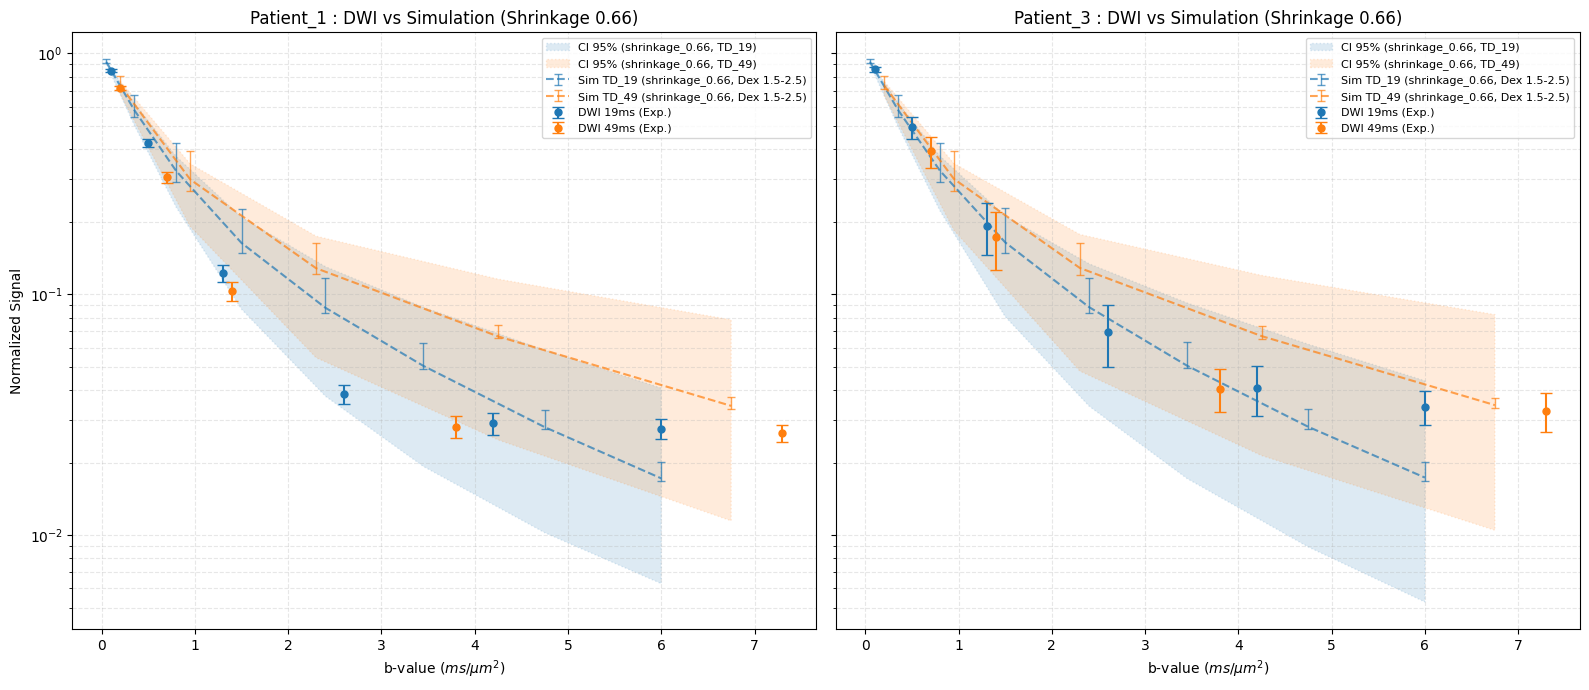

In [ ]:
with open("signal_results_shrinkage.json", "r", encoding='utf-8') as f:
    signal_json_shrinkage=json.load(f)

def plot_dwi_vs_shrinkage_bars_two_patients(df_dwi_list, signal_json, pat_ids, shrinkage_factor, max_b_histo=7.5):
    """
    Display DWI data vs simulation with a specific shrinkage factor for two patients side by side.
    
    df_dwi_list : list of DWI DataFrames, one per patient
    pat_ids : list of patient IDs corresponding to df_dwi_list
    shrinkage_factor : float, the shrinkage factor used in simulation
    max_b_histo : maximum b-value for histology display (ms/um²)
    """
    Dex_min, Dex_central, Dex_max = 1.5, 2.2, 2.5
    exp_selected = "exp_4"
    TD_colors = {'TD_19': 'tab:blue', 'TD_49': 'tab:orange'}
    
    sh_key = f"shrinkage_{shrinkage_factor}"
    
    # Create figure with two subplots side by side
    fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
    
    for ax, df_dwi, pat_id in zip(axes, df_dwi_list, pat_ids):
        # --- 1. SIMULATION WITH SHRINKAGE ---
        if pat_id in signal_json:
            he_key = list(signal_json[pat_id].keys())[0]
            
            if exp_selected in signal_json[pat_id][he_key]:
                roi_data_all = signal_json[pat_id][he_key][exp_selected]
                first_roi = list(roi_data_all.keys())[0]
                data_sh = roi_data_all[first_roi][sh_key]
                
                for TD_key in sorted(data_sh.keys()):
                    color = TD_colors.get(TD_key, 'black')
                    
                    # Extract Dex-sensitive curves
                    d_c = data_sh[TD_key][f"Dex_{Dex_central}"]
                    d_min = data_sh[TD_key][f"Dex_{Dex_min}"]
                    d_max = data_sh[TD_key][f"Dex_{Dex_max}"]

                    b_h = np.array(d_c["bval"])
                    mask = b_h <= max_b_histo
                    
                    s_central = np.array(d_c["signals_median"])[mask]
                    s_min = np.array(d_min["signals_median"])[mask]
                    s_max = np.array(d_max["signals_median"])[mask]
                    
                    # Asymmetric error bars for Dex sensitivity
                    yerr_dex = [
                        np.abs(s_central - s_max),  # Lower error
                        np.abs(s_min - s_central)   # Upper error
                    ]
                    
                    # Plot simulation central curve with Dex error bars
                    ax.errorbar(
                        b_h[mask], s_central, yerr=yerr_dex,
                        fmt='--', color=color, alpha=0.7, capsize=3, elinewidth=1,
                        label=f"Sim {TD_key} ({sh_key}, Dex {Dex_min}-{Dex_max})"
                    )
                    
                    # Plot confidence interval envelope from simulation
                    ax.fill_between(
                        b_h[mask],
                        np.array(d_c["p_low"])[mask],
                        np.array(d_c["p_high"])[mask],
                        color=color, alpha=0.15, linestyle=':',
                        label=f"CI 95% ({sh_key}, {TD_key})"
                    )

        # --- 2. REAL DWI DATA ---
        df_filtered = df_dwi[df_dwi['b_value'] <= max_b_histo*1000].copy()
        
        for td_label in df_filtered['TD'].unique():
            subset = df_filtered[df_filtered['TD'] == td_label]
            color_dwi = TD_colors.get(f"TD_{td_label.replace('ms','')}", 'black')
            
            ax.errorbar(
                subset['b_value']/1000,
                subset['signal'],
                yerr=subset['std'],
                fmt='o',
                color=color_dwi,
                ecolor=color_dwi,
                elinewidth=1.5,
                capsize=4,
                markersize=5,
                label=f"DWI {td_label} (Exp.)",
                zorder=5
            )
        
        # --- AXIS CONFIGURATION ---
        ax.set_yscale('log') 
        ax.set_xlabel("b-value ($ms/\\mu m^2$)")
        ax.set_title(f"{pat_id} : DWI vs Simulation (Shrinkage factor {shrinkage_factor})")
        ax.grid(True, which="both", linestyle='--', alpha=0.3)
        ax.legend(fontsize=8, ncol=1, loc='upper right')
    
    axes[0].set_ylabel("Normalized Signal")
    plt.tight_layout()
    plt.show()


# --- USAGE EXAMPLE ---
plot_dwi_vs_shrinkage_bars_two_patients([df_p1, df_p3], signal_json_shrinkage, ["Patient_1", "Patient_3"], shrinkage_factor=0.66)

# Comparison DWI VS particular geometries

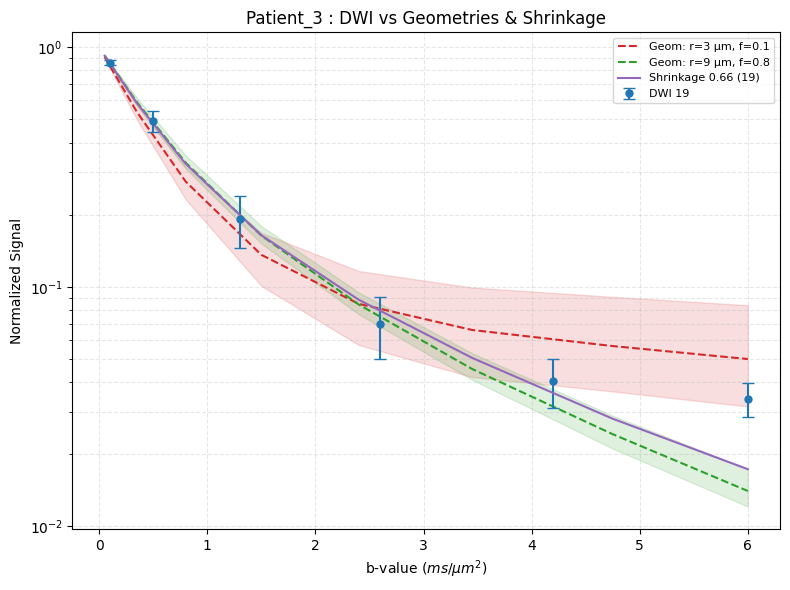

In [39]:
with open("signal_results_geom.json", "r", encoding="utf-8") as f:
    signal_json_geom = json.load(f)

def plot_dwi_geom_and_shrinkage(df_dwi, signal_json_geom, signal_json_shrinkage,
                               patient_id, TD_choice, geom1, geom2, shrinkage_factor,
                               Dex_central=2.2, max_b_histo=7.5):
    """
    Plot DWI, two geometries, and one shrinkage curve for a single patient.
    
    df_dwi : DataFrame du patient
    signal_json_geom : dictionnaire des simulations géométriques
    signal_json_shrinkage : dictionnaire des simulations avec shrinkage
    patient_id : str, nom du patient
    TD_choice : str, ex "19ms"
    geom1, geom2 : tuples (r_key, f_key)
    shrinkage_factor : float, facteur de shrinkage à afficher
    """
    TD_colors = { 'TD_19': 'tab:blue', 'TD_49': 'tab:orange' }
    geom_colors = ['tab:red', 'tab:green']
    shrink_color = 'tab:purple'

    fig, ax = plt.subplots(1,1,figsize=(8,6))
    
    # --- 1. Tracer les deux géométries ---
    for idx, (r_key, f_key) in enumerate([geom1, geom2]):
        data_geom = signal_json_geom[r_key][f_key][f"TD_{TD_choice}"][f"Dex_{Dex_central}"]
        bvals = np.array(data_geom["bval"])
        mask = bvals <= max_b_histo
        bvals = bvals[mask]
        signals = np.array(data_geom["signals_median"])[mask]
        color = geom_colors[idx % len(geom_colors)]
        
        r_val = r_key.split("_")[1]
        f_val = f_key.split("_")[1]
        ax.plot(bvals, signals, '--', color=color, label=f"Geom: r={r_val} μm, f={f_val}")
        # Intervalle de confiance
        p_low = np.array(data_geom["p_low"])[mask]
        p_high = np.array(data_geom["p_high"])[mask]
        ax.fill_between(bvals, p_low, p_high, color=color, alpha=0.15)
    
    # --- 2. Tracer DWI réel ---
    df_filtered = df_dwi[df_dwi['b_value'] <= max_b_histo*1000].copy()
    subset = df_filtered[df_filtered['TD'] == f"{TD_choice}ms"]
    color_dwi = TD_colors.get(f"TD_{TD_choice}", 'black')
    ax.errorbar(subset['b_value']/1000, subset['signal'], 
                yerr=subset['std'], fmt='o', color=color_dwi, 
                ecolor=color_dwi, capsize=4, markersize=5, label=f"DWI {TD_choice}")
    
    # --- 3. Tracer courbe shrinkage ---
    if patient_id in signal_json_shrinkage:
        he_key = list(signal_json_shrinkage[patient_id].keys())[0]
        exp_selected = "exp_4"
        if exp_selected in signal_json_shrinkage[patient_id][he_key]:
            roi_data_all = signal_json_shrinkage[patient_id][he_key][exp_selected]
            first_roi = list(roi_data_all.keys())[0]
            sh_key = f"shrinkage_{shrinkage_factor}"
            if sh_key in roi_data_all[first_roi]:
                data_sh = roi_data_all[first_roi][sh_key]
                if f"TD_{TD_choice}" in data_sh:
                    d_c = data_sh[f"TD_{TD_choice}"][f"Dex_{Dex_central}"]
                    bvals_sh = np.array(d_c["bval"])
                    mask_sh = bvals_sh <= max_b_histo
                    s_sh = np.array(d_c["signals_median"])[mask_sh]
                    ax.plot(bvals_sh[mask_sh], s_sh, '-', color=shrink_color,
                            label=f"Shrinkage {shrinkage_factor} ({TD_choice})")
    
    # --- Formatage final ---
    ax.set_yscale('log')
    ax.set_xlabel("b-value ($ms/\\mu m^2$)")
    ax.set_ylabel("Normalized Signal")
    ax.set_title(f"{patient_id} : DWI vs Geometries & Shrinkage")
    ax.grid(True, which='both', linestyle='--', alpha=0.3)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

plot_dwi_geom_and_shrinkage(
    df_dwi=df_p3,
    signal_json_geom=signal_json_geom,
    signal_json_shrinkage=signal_json_shrinkage,
    patient_id="Patient_3",
    TD_choice="19",
    geom1=("r_3","f_0.1"),
    geom2=("r_9","f_0.8"),
    shrinkage_factor=0.66
)